In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import brier_score_loss,average_precision_score
from sklearn.inspection import permutation_importance

from cdc_ml.config import POLLS_PROCESSED,PREFERENCE_PROCESSED,CUSTOMER_CLASS_PROCESSED
from cdc_ml.features.build_features import assign_class_type,drop_meta_high_card_cols
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from cdc_ml.modeling.train import train,StratifiedUsernameKFold
from matplotlib.ticker import PercentFormatter
from cdc_ml.features.build_features import drop_meta_high_card_cols
from cdc_ml.plots import platt_recal
from matplotlib.gridspec import GridSpec

In [98]:
df = pd.read_parquet(POLLS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [99]:
df_class.head()

,username,class_type,is_one_team
0,admin user,3a,0
1,jj,3a,0
2,b,3a,0
3,g,3a,0
4,shahtiya,CLASS 3 PRACTICAL TEST,0


In [100]:
df_pref.head(20)

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,Tuesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,0,0,0,0,0,1,1
1,0,ajithak,2,Wednesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-20 00:00:00+08:00,0,0,0,0,0,1,1
2,0,ajithak,3,Thursday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-21 00:00:00+08:00,0,0,0,0,0,1,1
3,0,ajithak,4,Friday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-22 00:00:00+08:00,0,0,0,0,0,1,1
4,0,ajithak,5,Saturday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-23 00:00:00+08:00,0,0,0,0,0,1,1
5,0,ajithak,6,Sunday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-24 00:00:00+08:00,1,1,1,1,1,1,1
6,0,ajithak,0,Monday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-25 00:00:00+08:00,0,0,0,0,0,1,1
7,0,ajithak,1,Tuesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-26 00:00:00+08:00,0,0,0,0,0,1,1
8,0,ajithak,2,Wednesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-27 00:00:00+08:00,0,0,0,0,0,1,1
9,0,ajithak,3,Thursday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-28 00:00:00+08:00,0,0,0,0,0,1,1


In [101]:
df= assign_class_type(df,df_class)

In [102]:
df.head()

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:00:00+08:00,False,8,19,1,9,8,19,1,9,-0.25,0,0
1,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:00:00+08:00,False,8,19,1,9,8,19,1,10,0.75,0,0
2,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 11:00:00+08:00,False,8,19,1,9,8,19,1,11,1.75,0,0
3,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 12:00:00+08:00,False,8,19,1,9,8,19,1,12,2.75,0,0
4,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 13:00:00+08:00,False,8,19,1,9,8,19,1,13,3.75,0,0


In [103]:
df_pref_melt = df_pref.melt(
    id_vars=["id","username","day_of_week","date"],
    value_vars=["t_0830","t_1020","t_1245","t_1435","t_1625","t_1850","t_2040"],
    var_name="timeslot",
    value_name="selected"

)
df_pref_melt.head()

,id,username,day_of_week,date,timeslot,selected
0,0,ajithak,1,2025-08-19 00:00:00+08:00,t_0830,0
1,0,ajithak,2,2025-08-20 00:00:00+08:00,t_0830,0
2,0,ajithak,3,2025-08-21 00:00:00+08:00,t_0830,0
3,0,ajithak,4,2025-08-22 00:00:00+08:00,t_0830,0
4,0,ajithak,5,2025-08-23 00:00:00+08:00,t_0830,0


In [104]:
# temp = df_pref_melt.groupby(["id","timeslot"])["selected"].sum()
# print(temp)
pref_days_count = df_pref.groupby("id").size().reset_index(name="pref_days_count")
#print(total_pref_occurance)


pref_dow = df_pref.groupby(["id","day_of_week"]).size().reset_index(name="pref_dow_count")
#print(pref_dow)


df_pref_melt = df_pref_melt.loc[df_pref_melt["selected"]==1].drop_duplicates(subset=["id","day_of_week","timeslot"]).sort_values(by="id")
#print(df_pref_melt.head(5))
coverage = df_pref_melt.groupby(["id"]).size().reset_index(name="pref_coverage")
#print(width)

pref_unique_day = df_pref.groupby(["id"])["day_of_week"].nunique().reset_index(name="pref_unique_day")
#print(pref_unique_day)


pref_unique_timeslot = df_pref_melt.groupby(["id"])["timeslot"].nunique().reset_index(name="pref_unique_timeslot")
print(pref_unique_timeslot)






      id  pref_unique_timeslot
0      0                     7
1      1                     7
2      2                     7
3      3                     7
4      4                     5
..   ...                   ...
115  117                     7
116  118                     7
117  119                     3
118  120                     2
119  121                     7

[120 rows x 2 columns]


In [105]:
df = df.merge(coverage,on='id',how="left")
df = df.merge(pref_days_count,on="id",how="left")
df = df.merge(pref_unique_day,on="id",how="left")
df = df.merge(pref_unique_timeslot,on="id",how="left")
print(df)

pref_dow_wide = (
    pref_dow
    .pivot(index="id", columns="day_of_week", values="pref_dow_count")
    .reindex(columns=range(7))        # force all 7 dows even if some never appear
    .fillna(0)                        # no row for a day => 0 prefs that day
    .astype("int64")
    .add_prefix("pref_dow_count_")    # pref_dow_count_0 ... pref_dow_count_6
    .rename_axis(columns=None)
    .reset_index()
)

n_before = len(df)
df = df.merge(pref_dow_wide, on="id", how="left")
assert len(df) == n_before, "merge fanned out — pref_dow_wide isn't unique per id"
df.head()

        id username               cycle_start                 cycle_end  \
0        0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
1        0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
2        0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
3        0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
4        0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
...    ...      ...                       ...                       ...   
32487  121   addity 2025-10-16 00:00:00+08:00 2025-10-17 20:00:00+08:00   
32488  121   addity 2025-10-16 00:00:00+08:00 2025-10-17 20:00:00+08:00   
32489  121   addity 2025-10-16 00:00:00+08:00 2025-10-17 20:00:00+08:00   
32490  121   addity 2025-10-16 00:00:00+08:00 2025-10-17 20:00:00+08:00   
32491  121   addity 2025-10-16 00:00:00+08:00 2025-10-17 20:00:00+08:00   

                     polling_at  has_booking  cycle_start_month  \
0     2025-08-19 09:00:00+08:00 

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_days_count,pref_unique_day,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:00:00+08:00,False,8,19,1,9,...,13.0,7.0,7.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0
1,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:00:00+08:00,False,8,19,1,9,...,13.0,7.0,7.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0
2,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 11:00:00+08:00,False,8,19,1,9,...,13.0,7.0,7.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0
3,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 12:00:00+08:00,False,8,19,1,9,...,13.0,7.0,7.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0
4,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 13:00:00+08:00,False,8,19,1,9,...,13.0,7.0,7.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0


In [106]:
print(df.head(1))
print(df_pref.head(1))

   id username               cycle_start                 cycle_end  \
0   0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   

                 polling_at  has_booking  cycle_start_month  cycle_start_day  \
0 2025-08-19 09:00:00+08:00        False                  8               19   

   cycle_start_dow  cycle_start_hour  ...  pref_days_count  pref_unique_day  \
0                1                 9  ...             13.0              7.0   

   pref_unique_timeslot  pref_dow_count_0  pref_dow_count_1  pref_dow_count_2  \
0                   7.0               1.0               2.0               2.0   

   pref_dow_count_3  pref_dow_count_4  pref_dow_count_5  pref_dow_count_6  
0               2.0               2.0               2.0               2.0  

[1 rows x 28 columns]
   id username  day_of_week day_name                pref_start  \
0   0  ajithak            1  Tuesday 2025-08-19 00:00:00+08:00   

                   pref_end                      date  t_0830  t_102

In [107]:
temp = df_pref.drop_duplicates(subset=['id'])
df = df.merge(temp[["id","pref_end","pref_start"]],on="id",how="left")
pref_range = (df["pref_end"] - df["pref_start"]).dt.total_seconds()/3600
poll_range = (df["pref_end"] - df["polling_at"]).dt.total_seconds()/3600
df["countdown"] = np.minimum(pref_range,poll_range)

print(df[["id","polling_at","pref_start","pref_end","countdown"]])

        id                polling_at                pref_start  \
0        0 2025-08-19 09:00:00+08:00 2025-08-19 00:00:00+08:00   
1        0 2025-08-19 10:00:00+08:00 2025-08-19 00:00:00+08:00   
2        0 2025-08-19 11:00:00+08:00 2025-08-19 00:00:00+08:00   
3        0 2025-08-19 12:00:00+08:00 2025-08-19 00:00:00+08:00   
4        0 2025-08-19 13:00:00+08:00 2025-08-19 00:00:00+08:00   
...    ...                       ...                       ...   
32487  121 2025-10-17 16:00:00+08:00 2025-10-16 00:00:00+08:00   
32488  121 2025-10-17 17:00:00+08:00 2025-10-16 00:00:00+08:00   
32489  121 2025-10-17 18:00:00+08:00 2025-10-16 00:00:00+08:00   
32490  121 2025-10-17 19:00:00+08:00 2025-10-16 00:00:00+08:00   
32491  121 2025-10-17 20:00:00+08:00 2025-10-16 00:00:00+08:00   

                       pref_end  countdown  
0     2025-08-31 00:00:00+08:00      279.0  
1     2025-08-31 00:00:00+08:00      278.0  
2     2025-08-31 00:00:00+08:00      277.0  
3     2025-08-31 00:00:00+0

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32492 entries, 0 to 32491
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   id                    32492 non-null  int64                         
 1   username              32492 non-null  str                           
 2   cycle_start           32492 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end             32492 non-null  datetime64[us, Asia/Singapore]
 4   polling_at            32492 non-null  datetime64[us, Asia/Singapore]
 5   has_booking           32492 non-null  bool                          
 6   cycle_start_month     32492 non-null  int32                         
 7   cycle_start_day       32492 non-null  int32                         
 8   cycle_start_dow       32492 non-null  int32                         
 9   cycle_start_hour      32492 non-null  int32                         
 10  polling_m

In [109]:
df_train, df_test = StratifiedUsernameKFold(df)


Train share -> 0.7963190939308138
Test share -> 0.20368090606918626
Baseline positive rate -> 0.012187615413024745
Train positive rate -> 0.012483574244415242
Test positive rate -> 0.011030522816560894


In [110]:
df_train.head(1)

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,pref_end,pref_start,countdown
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:00:00+08:00,False,8,19,1,9,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,279.0


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32492 entries, 0 to 32491
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   id                    32492 non-null  int64                         
 1   username              32492 non-null  str                           
 2   cycle_start           32492 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end             32492 non-null  datetime64[us, Asia/Singapore]
 4   polling_at            32492 non-null  datetime64[us, Asia/Singapore]
 5   has_booking           32492 non-null  bool                          
 6   cycle_start_month     32492 non-null  int32                         
 7   cycle_start_day       32492 non-null  int32                         
 8   cycle_start_dow       32492 non-null  int32                         
 9   cycle_start_hour      32492 non-null  int32                         
 10  polling_m

In [112]:
baseline = ["polling_hour","polling_dow"]
pref_coverage=["pref_coverage"]
countdown=["countdown"]
pref_unique_day=["pref_unique_day"]
pref_unique_timeslot=["pref_unique_timeslot"]
pref_dow=["pref_dow_count_0","pref_dow_count_1","pref_dow_count_2","pref_dow_count_3","pref_dow_count_4","pref_dow_count_5","pref_dow_count_6"]
class_features = ["is_one_team","class_type"]
test_list = {
    "baseline":                    baseline,
    "baseline+pref_dow":baseline+pref_dow,
    "baseline+pref_unique_day":                    baseline+pref_unique_day,
    "baseline+pref_unique_timeslot":                    baseline+pref_unique_timeslot,
    "baseline+pref_unique_day+pref_unique_timeslot":                    baseline+pref_unique_day+pref_unique_timeslot,
    "baseline+countdown":baseline+countdown,
    "baseline+pref_coverage":                    baseline+pref_coverage,
    "baseline+pref_coverage+countdown":baseline+pref_coverage+countdown,
    "baseline+pref_coverage+countdown+pref_dow":baseline+pref_coverage+countdown+pref_dow,
    "baseline+pref_unique_day+pref_unique_timeslot+countdown":                    baseline+pref_unique_day+pref_unique_timeslot+countdown,
    "baseline+pref_unique_day+pref_unique_timeslot+countdown+pref_coverage":                    baseline+pref_unique_day+pref_unique_timeslot+countdown+pref_coverage,
    "baseline+pref_unique_day+pref_unique_timeslot+countdown+pref_coverage+class_feature":                    baseline+pref_unique_day+pref_unique_timeslot+countdown+pref_coverage+class_features,
}

In [113]:
df_train.head(2)

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,pref_end,pref_start,countdown
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:00:00+08:00,False,8,19,1,9,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,279.0
1,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:00:00+08:00,False,8,19,1,9,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,278.0


In [ ]:
seeds = np.random.default_rng(0).choice(10_000, size=1, replace=False)

xgb_pr_auc= {m: [] for m in test_list}
for seed in seeds:
    for model,model_features in test_list.items():
        oof_xgb, *_ = train(df_train, model_features,seed=int(seed))
        score=average_precision_score(df_train["has_booking"], oof_xgb)
        xgb_pr_auc[model].append(score)

fold 0: train n= 20681 val n=  5193   train_pos=0.013  val_pos=0.011
  marg_dow  brier=0.0105  pr=0.0128
  marg_hour brier=0.0104  pr=0.0212
  add       brier=0.0104  pr=0.0247
  joint     brier=0.0105  pr=0.0253
  rf        brier=0.0104  pr=0.0255
  xgb (val) brier=0.0104  pr=0.0244
  xgb (tr)  brier=0.0126  pr=0.0352

fold 1: train n= 20390 val n=  5484   train_pos=0.014  val_pos=0.007
  marg_dow  brier=0.0071  pr=0.0088
  marg_hour brier=0.0072  pr=0.0093
  add       brier=0.0072  pr=0.0114
  joint     brier=0.0073  pr=0.0102
  rf        brier=0.0073  pr=0.0110
  xgb (val) brier=0.0072  pr=0.0110
  xgb (tr)  brier=0.0135  pr=0.0397

fold 2: train n= 20955 val n=  4919   train_pos=0.011  val_pos=0.021
  marg_dow  brier=0.0204  pr=0.0256
  marg_hour brier=0.0202  pr=0.0390
  add       brier=0.0201  pr=0.0514
  joint     brier=0.0203  pr=0.0380
  rf        brier=0.0202  pr=0.0440
  xgb (val) brier=0.0201  pr=0.0501
  xgb (tr)  brier=0.0103  pr=0.0270

fold 3: train n= 20706 val n=  516

In [ ]:
metric_eval = (
    pd.DataFrame(
        {
            "model": xgb_pr_auc.keys(),
            "mean": [np.mean(v) for v in xgb_pr_auc.values()],
            "std": [np.std(v) for v in xgb_pr_auc.values()],
        }
    )
)

In [ ]:
metric_eval

,model,mean,std
0,baseline,0.023867,0.0
1,baseline+pref_unique_day,0.033315,0.0
2,baseline+pref_unique_timeslot,0.035127,0.0
3,baseline+pref_unique_day+pref_unique_timeslot,0.046118,0.0
4,baseline+countdown,0.029360,0.0
5,baseline+pref_coverage,0.049781,0.0
6,baseline+pref_coverage+countdown,0.059446,0.0
7,baseline+pref_unique_day+pref_unique_timeslot+...,0.059766,0.0
8,baseline+pref_unique_day+pref_unique_timeslot+...,0.060148,0.0
9,baseline+pref_unique_day+pref_unique_timeslot+...,0.079669,0.0


In [ ]:
# from scipy import stats
# import numpy as np

# diff  = np.asarray(xgb_pr_auc["baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage"]) - np.asarray(xgb_pr_auc["baseline+pref_unique_day+pref_unique_timeslot+pref_days_count"])     # paired, row-wise by iteration
# d_bar = diff.mean()                              # = +0.0019, your point estimate
# t, p  = stats.ttest_rel(xgb_pr_auc["baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage"], xgb_pr_auc["baseline+pref_unique_day+pref_unique_timeslot+pref_days_count"])  # two-sided
# ci    = stats.t.interval(0.95, len(diff)-1, loc=d_bar,
#                          scale=diff.std(ddof=1)/np.sqrt(len(diff)))
# n_pos = (diff > 0).sum()                         # how many of 20 seeds favored dow

# print(d_bar)
# print(t,p)
# print(ci)
# print(n_pos)

In [ ]:
seeds = np.random.default_rng(0).choice(10_000, size=1, replace=False)

xgb_pr_auc_6 = {m: [] for m in test_list}
for seed in seeds:
    for model,model_features in test_list.items():
        oof_xgb, *_ = train(df_train, model_features,seed=int(seed))
        score=average_precision_score(df_train["has_booking"], oof_xgb)
        xgb_pr_auc_6[model].append(score)

fold 0: train n= 20681 val n=  5193   train_pos=0.013  val_pos=0.011
  marg_dow  brier=0.0105  pr=0.0128
  marg_hour brier=0.0104  pr=0.0212
  add       brier=0.0104  pr=0.0247
  joint     brier=0.0105  pr=0.0253
  rf        brier=0.0104  pr=0.0255
  xgb (val) brier=0.0104  pr=0.0244
  xgb (tr)  brier=0.0126  pr=0.0352

fold 1: train n= 20390 val n=  5484   train_pos=0.014  val_pos=0.007
  marg_dow  brier=0.0071  pr=0.0088
  marg_hour brier=0.0072  pr=0.0093
  add       brier=0.0072  pr=0.0114
  joint     brier=0.0073  pr=0.0102
  rf        brier=0.0073  pr=0.0110
  xgb (val) brier=0.0072  pr=0.0110
  xgb (tr)  brier=0.0135  pr=0.0397

fold 2: train n= 20955 val n=  4919   train_pos=0.011  val_pos=0.021
  marg_dow  brier=0.0204  pr=0.0256
  marg_hour brier=0.0202  pr=0.0390
  add       brier=0.0201  pr=0.0514
  joint     brier=0.0203  pr=0.0380
  rf        brier=0.0202  pr=0.0440
  xgb (val) brier=0.0201  pr=0.0501
  xgb (tr)  brier=0.0103  pr=0.0270

fold 3: train n= 20706 val n=  516

In [ ]:
metric_eval_6 = (
    pd.DataFrame(
        {
            "model": xgb_pr_auc_6.keys(),
            "mean": [np.mean(v) for v in xgb_pr_auc_6.values()],
            "std": [np.std(v) for v in xgb_pr_auc_6.values()],
        }
    )
)

In [ ]:
metric_eval_6

,model,mean,std
0,baseline,0.023867,0.0
1,baseline+pref_unique_day,0.033315,0.0
2,baseline+pref_unique_timeslot,0.035127,0.0
3,baseline+pref_unique_day+pref_unique_timeslot,0.046118,0.0
4,baseline+countdown,0.029360,0.0
5,baseline+pref_coverage,0.049781,0.0
6,baseline+pref_coverage+countdown,0.059446,0.0
7,baseline+pref_unique_day+pref_unique_timeslot+...,0.059766,0.0
8,baseline+pref_unique_day+pref_unique_timeslot+...,0.060148,0.0
9,baseline+pref_unique_day+pref_unique_timeslot+...,0.079669,0.0


In [ ]:
# from scipy import stats
# import numpy as np

# diff  = np.asarray(xgb_pr_auc_6["baseline+pref_width+pref_dow"]) - np.asarray(xgb_pr_auc_6["baseline+pref_width"])     # paired, row-wise by iteration
# d_bar = diff.mean()                              # = +0.0019, your point estimate
# t, p  = stats.ttest_rel(xgb_pr_auc_6["baseline+pref_width+pref_dow"], xgb_pr_auc_6["baseline+pref_width"])  # two-sided
# ci    = stats.t.interval(0.95, len(diff)-1, loc=d_bar,
#                          scale=diff.std(ddof=1)/np.sqrt(len(diff)))
# n_pos = (diff > 0).sum()                         # how many of 20 seeds favored dow

# print(d_bar)
# print(t,p)
# print(ci)
# print(n_pos)

In [ ]:
chosen = baseline+pref_unique_day+pref_unique_timeslot+countdown+pref_coverage
#chosen = baseline

ValueError: Unable to coerce to Series, length must be 2: given 4

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold,GridSearchCV

# X = chosen feature set (polling_dow, polling_hour, pref_*)
# y = has_booking ; groups = df["username"]

base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=1,            # let the search parallelize instead
    random_state=42,
    # scale_pos_weight left at 1 on purpose — see note
)

param_dist = {
    "n_estimators":     [200, 400, 600, 800],
    "max_depth":        [2,3, 4, 5, 6],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 5, 10, 20, 50],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 1.0],     # near no-op with so few features
    "reg_lambda": [1, 5, 10,20],   # default is 1, so right now you're only sampling that one point
    "gamma":            [0, 0.5, 1.0, 2.0],
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

search = RandomizedSearchCV(
    base, param_dist, n_iter=50,
    scoring="average_precision",        # = PR-AUC, your reported metric
    cv=cv, n_jobs=-1, random_state=42, refit=True, verbose=1,
)
#search.fit(df_train[baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage], df_train["has_booking"], groups=df_train["username"])
search.fit(df_train[chosen], df_train["has_booking"], groups=df_train["username"])

print(search.best_score_, search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.07442915841314884 {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 200, 'min_child_weight': 20, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}


In [ ]:
final_model = search.best_estimator_
print(final_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=20, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=1, num_parallel_tree=None, ...)


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
oof_proba = cross_val_predict(
    clone(final_model), df_train[baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage], df_train["has_booking"],
    groups=df_train["username"], cv=cv, method="predict_proba", n_jobs=-1,
)[:, 1]

# Platt = logistic regression on the score's logit (not the prob itself).
eps = 1e-6
def to_logit(p):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

platt = LogisticRegression(C=1e6)        # large C ≈ unregularised, pure 2-param fit
platt.fit(to_logit(oof_proba).reshape(-1, 1), df_train["has_booking"])

def predict_calibrated(model, X):
    raw = model.predict_proba(X)[:, 1]
    return platt.predict_proba(to_logit(raw).reshape(-1, 1))[:, 1]

In [ ]:
#X_test, y_test = df_test[baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage], df_test["has_booking"]
whales_pt_mask = df_test["username"].isin(["anmol", "jy", "mya"]).to_numpy()
non_whales_pt_mask = ~df_test["username"].isin(["anmol", "jy", "mya"]).to_numpy()

X_test, y_test = df_test[chosen], df_test["has_booking"]

whale_base_rate = y_test[whales_pt_mask].mean()
non_whale_base_rate = y_test[~whales_pt_mask].mean()

print(f"whale base rate :{whale_base_rate}")
print(f"non whale base rate :{non_whale_base_rate}")
print()

p_raw = final_model.predict_proba(X_test)[:, 1]

whale_test_score = average_precision_score(y_test[whales_pt_mask],p_raw[whales_pt_mask])
non_whale_test_score = average_precision_score(y_test[~whales_pt_mask],p_raw[~whales_pt_mask])
overall_score = average_precision_score(y_test,p_raw)

whale_lift = whale_test_score/whale_base_rate
non_whale_lift = non_whale_test_score/non_whale_base_rate
print(f"whale score:{whale_test_score}")
print(f"non whale score:{non_whale_test_score}")
print(f"overall score:{overall_score}")
print()

print(f"whale_lift :{whale_lift}")
print(f"non whale_lift :{non_whale_lift}")
# print(test_score)
#p_cal = predict_calibrated(final_model, X_test)

whale base rate :0.015664690939881456
non whale base rate :0.008458646616541353

whale score:0.09613630278890285
non whale score:0.011855695055365375
overall score:0.02543417576273161

whale_lift :6.137133707767258
non whale_lift :1.4016066154343065


In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

# plug in your test arrays:
#   y_test      : 0/1 labels
#   score_test  : model predicted probs
#   user_test   : username/id per row
#   whale_mask  : bool, True = whale row
def pr_auc_ci_by_user(y, score, user_ids, n_boot=1000, seed=0):
    y, score, user_ids = map(np.asarray, (y, score, user_ids))
    base, point = y.mean(), average_precision_score(y, score)
    users = np.unique(user_ids)
    rows_by_user = {u: np.where(user_ids == u)[0] for u in users}
    rng, boots = np.random.default_rng(seed), []
    for _ in range(n_boot):
        idx = np.concatenate([rows_by_user[u] for u in rng.choice(users, len(users), replace=True)])
        if y[idx].sum() == 0:
            continue
        boots.append(average_precision_score(y[idx], score[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    print(f"users={len(users)} rows={len(y)} positives={int(y.sum())} base={base:.4f}")
    print(f"PR-AUC={point:.4f} ({point/base:.2f}x)  95% CI=[{lo:.4f}, {hi:.4f}] ([{lo/base:.2f}x, {hi/base:.2f}x])\n")


whale_users = df_test.loc[whales_pt_mask,["username"]]
non_whales_users = df_test.loc[non_whales_pt_mask,["username"]]
print("ALL");        pr_auc_ci_by_user(y_test, p_raw, df_test["username"])
print("WHALES");     pr_auc_ci_by_user(y_test[whales_pt_mask],  p_raw[whales_pt_mask],  whale_users)
print("NON-WHALES"); pr_auc_ci_by_user(y_test[~whales_pt_mask], p_raw[~whales_pt_mask], non_whales_users)

ALL
users=8 rows=6618 positives=73 base=0.0110
PR-AUC=0.0254 (2.31x)  95% CI=[0.0090, 0.0746] ([0.82x, 6.77x])

WHALES
users=1 rows=2362 positives=37 base=0.0157
PR-AUC=0.0961 (6.14x)  95% CI=[0.0961, 0.0961] ([6.14x, 6.14x])

NON-WHALES
users=7 rows=4256 positives=36 base=0.0085
PR-AUC=0.0119 (1.40x)  95% CI=[0.0080, 0.0346] ([0.95x, 4.09x])



In [ ]:
import numpy as np, pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# X_train, X_test : feature DataFrames with the SAME columns your model uses
def adversarial_validation(X_train, X_test):
    X = pd.concat([X_train, X_test], ignore_index=True)
    y = np.r_[np.zeros(len(X_train)), np.ones(len(X_test))]   # 0 = train, 1 = test
    clf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
    auc = cross_val_score(clf, X, y, cv=5, scoring="roc_auc").mean()
    print(f"adversarial AUC = {auc:.3f}   (0.5 = identical, ~0.65+ = real shift, 0.8+ = strong)")
    clf.fit(X, y)
    print(pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(8).to_string())

adversarial_validation(df_train[baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage], X_test[baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage])

adversarial AUC = 0.734   (0.5 = identical, ~0.65+ = real shift, 0.8+ = strong)
pref_days_count         0.397832
pref_coverage           0.295506
pref_unique_timeslot    0.187488
pref_unique_day         0.091484
polling_dow             0.014130
polling_hour            0.013560


In [ ]:
"""Calibration reliability diagrams segmented by polling-volume whales.

Drop into your viz/plotting module. Main entry point is
`plot_calibration_by_volume`, which takes pooled OOF predictions and plots
whale vs non-whale reliability curves with Wilson CIs plus prediction
histograms underneath.

Design choices baked in:
  * Segment on EXPOSURE (n_polls / is_whale), never on positive count — the
    slice must not be conditioned on the label.
  * Quantile (equal-count) bins, not equal-width, so no bin is mostly empty
    at the ~1.3% base rate. Edges are deduped, which also handles the
    discrete-prediction case (additive LUT emits one value per dow/hour cell).
  * Wilson score intervals for observed frequency — robust at low counts /
    extreme p, unlike the normal approximation.
  * Prediction histogram (log y) under the reliability axes so sparsity in the
    low-volume segment is visible rather than hidden.

Read points BELOW the diagonal as overprediction (observed < predicted) — the
non-whale failure mode you diagnosed.
"""

def wilson_interval(k, n, z=1.96):
    """95% Wilson score interval for a binomial proportion.

    Returns (p_hat, lower, upper). p_hat is the raw observed frequency (the
    plotted point); the interval is the Wilson score interval, which stays
    sensible when k is tiny or n is small.
    """
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(k, n, out=np.zeros_like(k, dtype=float), where=n > 0)
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    lower = np.clip(center - half, 0.0, 1.0)
    upper = np.clip(center + half, 0.0, 1.0)
    return p, lower, upper


def _quantile_bin_index(p_pred, n_bins):
    """Assign each prediction to a quantile bin. Dedups edges, so the effective
    number of bins may be < n_bins when predictions are discrete (LUT) or
    heavily point-massed. Returns (edges, idx, n_effective)."""
    edges = np.quantile(p_pred, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 2:  # all predictions identical
        return edges, np.zeros(len(p_pred), dtype=int), 1
    idx = np.clip(np.digitize(p_pred, edges[1:-1], right=False), 0, len(edges) - 2)
    return edges, idx, len(edges) - 1


def reliability_table(p_pred, y_true, n_bins=10):
    """Per-bin mean predicted prob, observed freq, Wilson CI, and count."""
    p_pred = np.asarray(p_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    _, idx, n_eff = _quantile_bin_index(p_pred, n_bins)

    x, k_arr, n_arr = [], [], []
    for b in range(n_eff):
        mask = idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        x.append(p_pred[mask].mean())
        k_arr.append(y_true[mask].sum())
        n_arr.append(n)

    x = np.array(x)
    k_arr = np.array(k_arr)
    n_arr = np.array(n_arr)
    obs, lo, hi = wilson_interval(k_arr, n_arr)
    return {"x": x, "obs": obs, "lo": lo, "hi": hi, "n": n_arr, "k": k_arr}


def plot_calibration_by_volume(
    p_pred,
    y_true,
    is_whale,
    *,
    n_bins=10,
    title="Calibration by polling volume (pooled OOF)",
    ax_range=None,
):
    """Reliability diagram for whale vs non-whale segments.

    Parameters
    ----------
    p_pred : array of predicted P(has_booking) per polling row (pooled OOF).
    y_true : array of 0/1 has_booking labels, same length.
    is_whale : bool array, True for high-n_polls users. Use the SAME whale
        definition as your baseline sweep so the graph matches your weighting.
    n_bins : requested quantile bins (effective count may be lower).
    """
    p_pred = np.asarray(p_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    is_whale = np.asarray(is_whale, dtype=bool)

    segments = {
        "whale (high n_polls)": (is_whale, "#2563eb"),
        "non-whale": (~is_whale, "#dc2626"),
    }

    if ax_range is None:
        hi_x = float(np.quantile(p_pred, 0.999))
        ax_range = (0.0, max(hi_x, float(y_true.mean()) * 3.0))

    fig = plt.figure(figsize=(10,5))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.07)
    ax = fig.add_subplot(gs[0])
    axh = fig.add_subplot(gs[1], sharex=ax)

    # perfect-calibration reference
    ax.plot(ax_range, ax_range, ls="--", lw=1.0, color="#6b7280", label="perfect", zorder=1)

    for name, (mask, color) in segments.items():
        if mask.sum() == 0:
            continue
        t = reliability_table(p_pred[mask], y_true[mask], n_bins=n_bins)
        yerr = np.vstack(
            [np.clip(t["obs"] - t["lo"], 0, None), np.clip(t["hi"] - t["obs"], 0, None)]
        )
        ax.errorbar(
            t["x"],
            t["obs"],
            yerr=yerr,
            marker="o",
            ms=4.5,
            lw=1.6,
            capsize=2.5,
            color=color,
            zorder=3,
            label=f"{name}  (base={y_true[mask].mean():.2%}, " f"N={mask.sum():,})",
        )
        axh.hist(p_pred[mask], bins=40, range=ax_range, alpha=0.5, color=color, label=name)

    ax.set_xlim(*ax_range)
    ax.set_ylim(0, ax_range[1])
    ax.set_ylabel("Observed frequency")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.text(
        0.97,
        0.04,
        "below diagonal = overprediction",
        transform=ax.transAxes,
        ha="right",
        fontsize=8.5,
        color="#6b7280",
        style="italic",
    )
    plt.setp(ax.get_xticklabels(), visible=False)

    axh.set_yscale("log")
    axh.set_ylabel("rows")
    axh.set_xlabel("Predicted P(has_booking)")
    axh.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    axh.legend(loc="upper right", fontsize=8, frameon=False)

    fig.align_ylabels([ax, axh])


Error in callback <function _draw_all_if_interactive at 0x0000018EBA803380> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

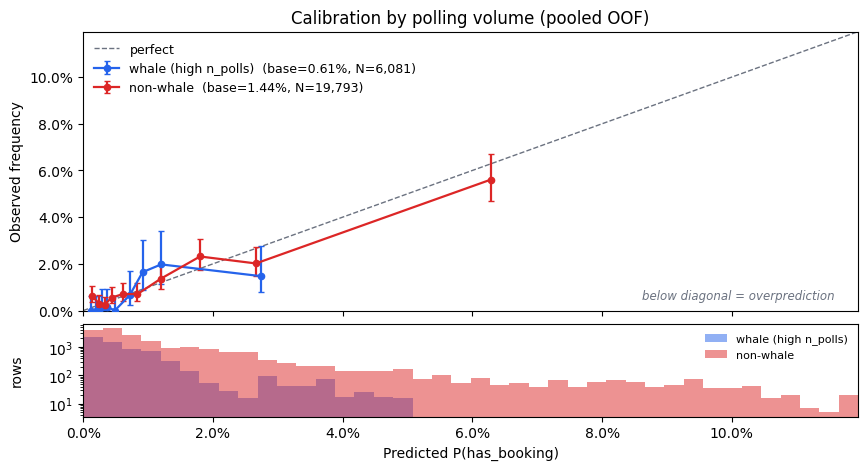

In [ ]:

whales_pt_mask = df_train["username"].isin(["kim", "jy", "flower"]).to_numpy()
plot_calibration_by_volume(oof_xgb,df_train["has_booking"].to_numpy(),whales_pt_mask)

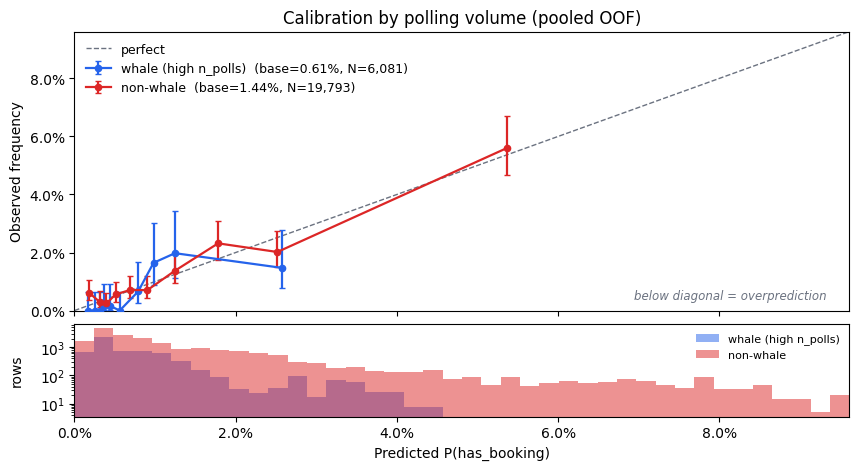

In [ ]:
p_cal , platt = platt_recal(oof_xgb,df_train)
plot_calibration_by_volume(p_cal,df_train["has_booking"],whales_pt_mask)

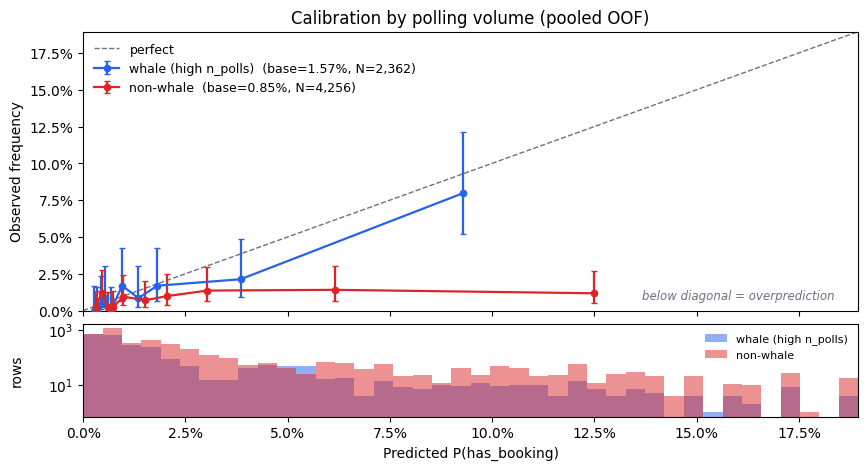

In [ ]:
# Train Platt calibrator on OOF predictions
# Raw test predictions
p_final = final_model.predict_proba(df_test[chosen])[:, 1]

# Convert test probabilities to logits
eps = 1e-6
p_final_clip = np.clip(p_final, eps, 1 - eps)
z_test = np.log(p_final_clip / (1 - p_final_clip)).reshape(-1, 1)

# Apply fitted Platt calibrator
p_final_cal = platt.predict_proba(z_test)[:, 1]

# Plot calibrated predictions
whales_pt_mask = df_test["username"].isin(["kim", "jy", "flower"]).to_numpy()

plot_calibration_by_volume(
    p_final_cal,
    df_test["has_booking"].to_numpy(),
    whales_pt_mask
)

poll 111/168 cells (66% of polling) -> 90% of bookings


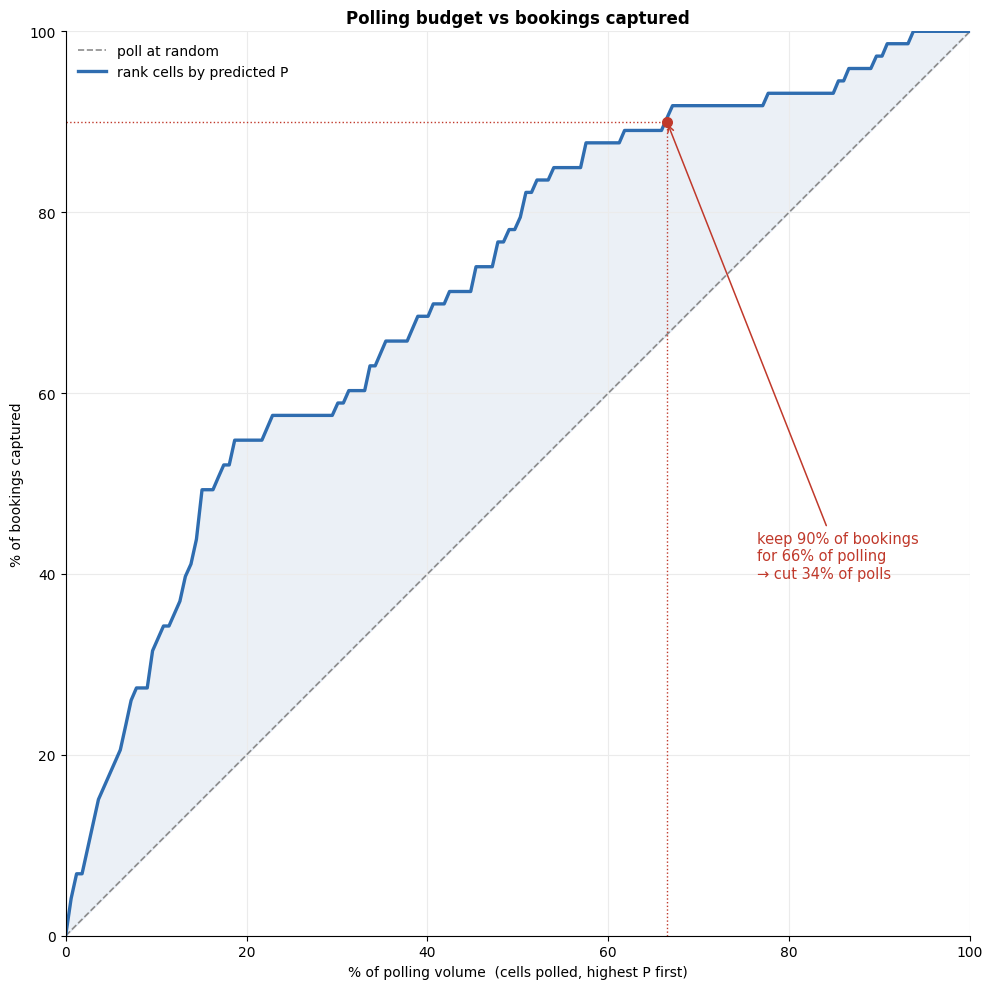

top 10% polling -> 32.9% bookings (lift 3.22x)
top 20% polling -> 54.8% bookings (lift 2.67x)
top 30% polling -> 58.9% bookings (lift 1.96x)
top 50% polling -> 79.5% bookings (lift 1.58x)
top 60% polling -> 87.7% bookings (lift 1.46x)


In [ ]:
cell = (
    df_test.assign(oof=p_final_cal)                    # oof_xgb is already row-aligned to df_train
            .groupby(["polling_dow", "polling_hour"])
            .agg(pred=("oof", "mean"),              # cell's predicted P (mean over folds)
                 polls=("has_booking", "size"),     # volume = rows in the cell
                 bookings=("has_booking", "sum"))   # actual bookings in the cell
            .reset_index()
            .sort_values("pred", ascending=False)   # rank cells by P — and DON'T re-sort after
            .reset_index(drop=True)
)
cell["cum_polls"]    = cell["polls"].cumsum()                       # ONE global cumsum down the ranking
cell["cum_bookings"] = cell["bookings"].cumsum()
cell["pct_polls"]    = cell["cum_polls"]    / cell["polls"].sum()    # x-axis: % of polling
cell["pct_bookings"] = cell["cum_bookings"] / cell["bookings"].sum() # y-axis: % of bookings caught
cell["lift"]         = cell["pct_bookings"] / cell["pct_polls"]

target_recall = 0.90                                                # keep 90% of bookings
tau = cell.loc[cell.pct_bookings >= target_recall, "pred"].iloc[0]  # implied threshold
cell["poll"] = cell["pred"] >= tau                                  # True = poll, else skip
schedule = cell.loc[cell.poll, ["polling_dow", "polling_hour", "pred"]]

print(f"poll {cell.poll.sum()}/{len(cell)} cells "
      f"({cell.loc[cell.poll,'polls'].sum()/cell.polls.sum():.0%} of polling) "
      f"-> {cell.loc[cell.poll,'bookings'].sum()/cell.bookings.sum():.0%} of bookings")

x = np.insert(cell["pct_polls"].to_numpy()*100, 0, 0)   # prepend origin
y = np.insert(cell["pct_bookings"].to_numpy()*100, 0, 0)

fig, ax = plt.subplots(figsize=(20,10))
ax.plot([0,100],[0,100], "--", color="0.55", lw=1.2, label="poll at random")
ax.fill_between(x, x, y, color="#3b6fb0", alpha=0.10)
ax.plot(x, y, color="#2f6db0", lw=2.4, label="rank cells by predicted P")

op = cell[cell["pct_bookings"] >= 0.90].iloc[0]          # smallest budget keeping 90% of bookings
ox = op["pct_polls"]*100
ax.scatter([ox],[90], s=48, color="#c0392b", zorder=6)
ax.vlines(ox, 0, 90, color="#c0392b", ls=":", lw=1)
ax.hlines(90, 0, ox, color="#c0392b", ls=":", lw=1)
ax.annotate(f"keep 90% of bookings\nfor {ox:.0f}% of polling\n→ cut {100-ox:.0f}% of polls",
            xy=(ox,90), xytext=(ox+10, 42), fontsize=10.5, color="#c0392b", va="center",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.1))

ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect("equal")
ax.set_xlabel("% of polling volume  (cells polled, highest P first)")
ax.set_ylabel("% of bookings captured")
ax.set_title("Polling budget vs bookings captured", fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, color="0.92", lw=0.8)
for s in ["top","right"]: ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

for k in (10, 20, 30, 50, 60):                               # numbers for your slide text
    r = cell[cell.pct_polls >= k/100].iloc[0]
    print(f"top {k:>2d}% polling -> {r.pct_bookings:5.1%} bookings (lift {r.lift:.2f}x)")

0.5909793615212182 for 0.9009287925696594


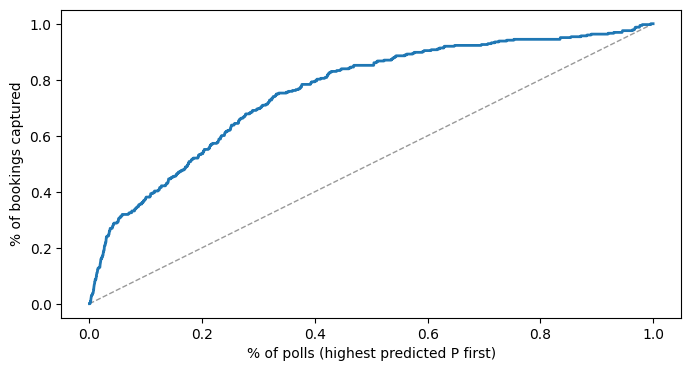

In [ ]:
final = (df_train.assign(predicted=oof_xgb)
         .groupby("predicted")
         .agg(count=("has_booking", "size"),
              bookings=("has_booking", "sum"))
         .sort_index(ascending=False))            # rank highest P first — the fix

final["polling_share"]   = final["count"].cumsum()    / final["count"].sum()
final["booking_share"] = final["bookings"].cumsum() / final["bookings"].sum()

x = np.r_[0, final["polling_share"].to_numpy()]        # prepend origin
y = np.r_[0, final["booking_share"].to_numpy()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1)   # random baseline
ax.plot(x, y, lw=2)
ax.set_xlabel("% of polls (highest predicted P first)")
ax.set_ylabel("% of bookings captured")

target_recall = 0.90                                                # keep 90% of bookings
tau = final.loc[final["booking_share"] >= target_recall].iloc[0]  # implied threshold
print(f"{tau["polling_share"]} for {tau["booking_share"]}")
#cell["poll"] = cell["pred"] >= tau    

Text(0, 0.5, '% of bookings captured')

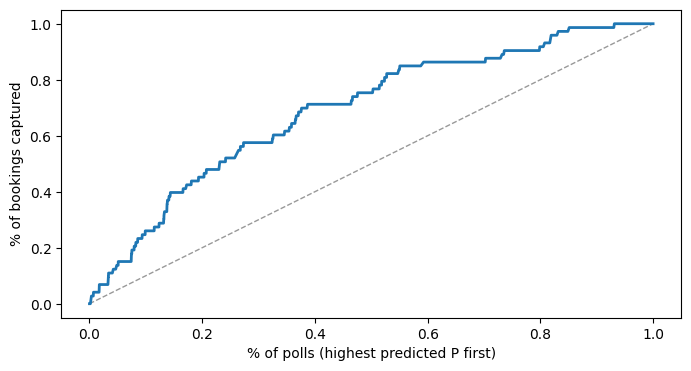

In [ ]:
final = (df_test.assign(predicted=p_final_cal)
         .groupby("predicted")
         .agg(count=("has_booking", "size"),
              bookings=("has_booking", "sum"))
         .sort_index(ascending=False))            # rank highest P first — the fix

final["cum_count"]   = final["count"].cumsum()    / final["count"].sum()
final["cum_booking"] = final["bookings"].cumsum() / final["bookings"].sum()

x = np.r_[0, final["cum_count"].to_numpy()]        # prepend origin
y = np.r_[0, final["cum_booking"].to_numpy()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1)   # random baseline
ax.plot(x, y, lw=2)
ax.set_xlabel("% of polls (highest predicted P first)")
ax.set_ylabel("% of bookings captured")

 booking whales: median recall 100%, worst 96%  (n=3)
       the rest: median recall 100%, worst 0%  (n=26)


<Axes: title={'center': 'recall'}, xlabel='whale'>

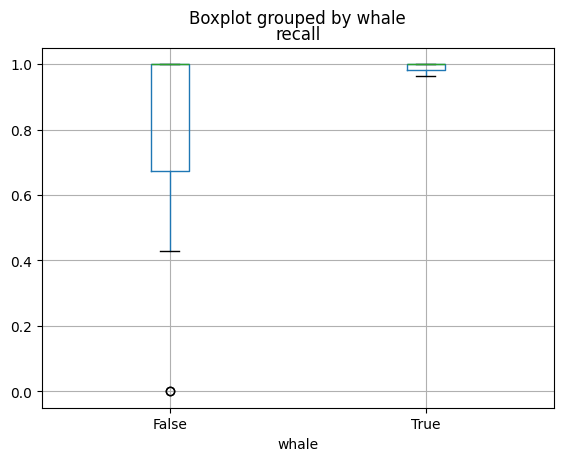

In [ ]:
def per_customer_at_budget(df, pred_col, budget=0.30,
                           user_col="username", label_col="has_booking"):
    p    = pred_col
    keep = p >= np.quantile(p, 1 - budget)        # poll iff P >= tau (top `budget` of polls)
    book = df[label_col].to_numpy(float)
    t = (df.assign(_caught=book*keep, _booking=book, _polled=keep.astype(float))
           .groupby(user_col)
           .agg(bookings=("_booking","sum"), caught=("_caught","sum"),
                polls=("_booking","size"),  polled=("_polled","sum")))
    t = t[t.bookings > 0]                          # recall undefined without bookings
    t["recall"]    = t.caught / t.bookings
    t["poll_kept"] = t.polled / t.polls
    t = t.sort_values("bookings", ascending=False)
    t["whale"] = t.bookings.cumsum() <= 0.5 * t.bookings.sum()   # top 50% of all bookings
    return t

t = per_customer_at_budget(df_train, oof_xgb, budget=0.60)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
t.boxplot("recall", by="whale")  # if you want the distribution, not just the summary

In [ ]:
import numpy as np

def _gains_curve(p, y):
    """Cumulative gains (x=frac polls, y=frac bookings), stepping at each distinct
    prediction so a threshold includes whole tie-groups. Origin prepended.
    Assumes one row = one poll (matches polls = size)."""
    order = np.argsort(-p, kind="stable")
    p, y  = p[order], y[order]
    cut   = np.r_[True, p[1:] != p[:-1]]              # start of each distinct-P run
    ends  = np.r_[np.flatnonzero(cut)[1:] - 1, p.size - 1]
    cum_polls    = np.arange(1, p.size + 1)
    cum_bookings = np.cumsum(y)
    x = np.r_[0.0, cum_polls[ends]    / cum_polls[-1]]
    yv = np.r_[0.0, cum_bookings[ends] / cum_bookings[-1]]
    return x, yv

def _budget_at_recall(x, y, r):
    j = np.searchsorted(y, r, side="left")            # first point with recall >= r
    if j == 0:
        return 0.0
    y0, y1, x0, x1 = y[j-1], y[j], x[j-1], x[j]
    return x0 if y1 == y0 else x0 + (r - y0) * (x1 - x0) / (y1 - y0)

def gains_bootstrap(df, pred_col, user_col="username", label_col="has_booking",
                    target_recall=0.90, n_boot=1000, grid=None, seed=0):
    rng  = np.random.default_rng(seed)
    grid = np.linspace(0.0, 1.0, 201) if grid is None else np.asarray(grid, float)
    p = df[pred_col].to_numpy(float)
    y = df[label_col].to_numpy(float)
    if y.sum() == 0:
        raise ValueError("no positive labels")

    idx = list(df.groupby(user_col, sort=False).indices.values())   # rows per user
    n_u = len(idx)

    x0, y0 = _gains_curve(p, y)                                      # point estimate
    point  = {"curve": np.interp(grid, x0, y0),
              "budget": _budget_at_recall(x0, y0, target_recall)}

    curves, budgets = np.empty((n_boot, grid.size)), np.empty(n_boot)
    for b in range(n_boot):
        rows  = np.concatenate([idx[i] for i in rng.integers(0, n_u, n_u)])
        xb, yb = _gains_curve(p[rows], y[rows])
        curves[b]  = np.interp(grid, xb, yb)
        budgets[b] = _budget_at_recall(xb, yb, target_recall)

    lo, med, hi = np.percentile(curves, [2.5, 50, 97.5], axis=0)
    return {"grid": grid, **point, "lo": lo, "med": med, "hi": hi,
            "budgets": budgets, "budget_ci": np.percentile(budgets, [2.5, 50, 97.5])}

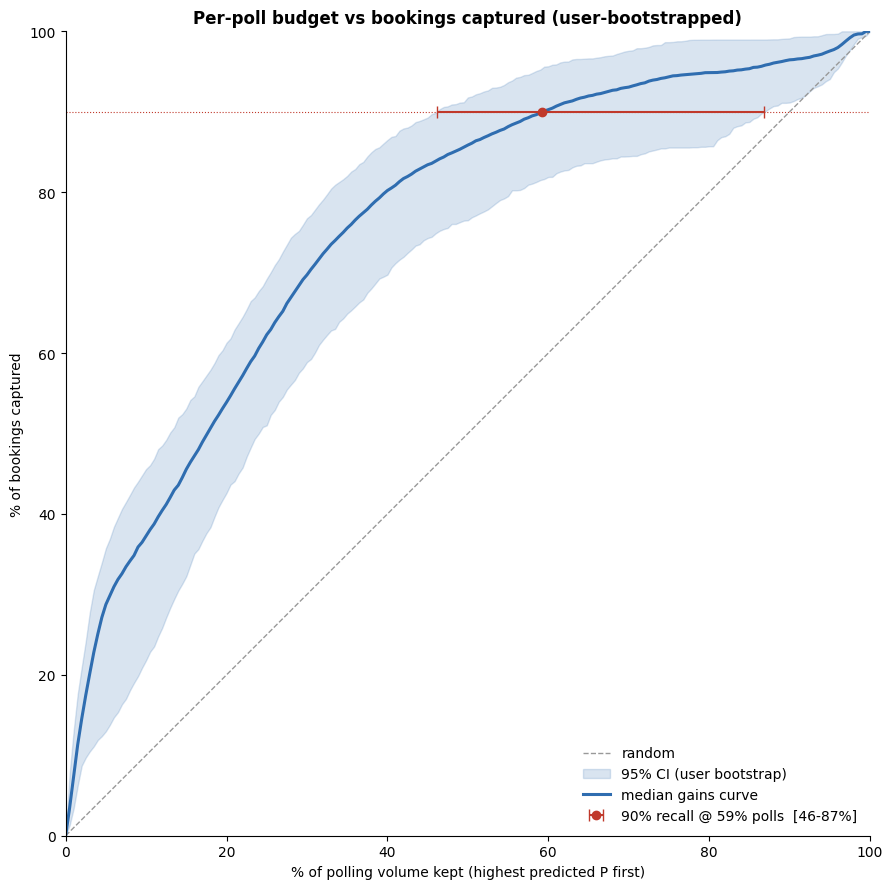

90% of bookings for 59% of polls (95% CI 46-87%)


In [ ]:
import matplotlib.pyplot as plt

# if your calibrated OOF preds are an array: df_train = df_train.assign(p_oof_cal=p_oof_cal)
df_train = df_train.assign(p_oof_cal=oof_xgb)
res = gains_bootstrap(df_train, pred_col="p_oof_cal")
g, lo, med, hi = res["grid"]*100, res["lo"]*100, res["med"]*100, res["hi"]*100
b_lo, b_med, b_hi = res["budget_ci"]*100

fig, ax = plt.subplots(figsize=(9, 9))
ax.plot([0,100],[0,100], "--", color="0.6", lw=1, label="random")
ax.fill_between(g, lo, hi, color="#2f6db0", alpha=0.18, label="95% CI (user bootstrap)")
ax.plot(g, med, color="#2f6db0", lw=2.2, label="median gains curve")
ax.errorbar(b_med, 90, xerr=[[b_med-b_lo],[b_hi-b_med]], fmt="o", color="#c0392b",
            capsize=4, zorder=6,
            label=f"90% recall @ {b_med:.0f}% polls  [{b_lo:.0f}-{b_hi:.0f}%]")
ax.axhline(90, color="#c0392b", ls=":", lw=0.8)
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect("equal")
ax.set_xlabel("% of polling volume kept (highest predicted P first)")
ax.set_ylabel("% of bookings captured")
ax.set_title("Per-poll budget vs bookings captured (user-bootstrapped)", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

print(f"90% of bookings for {res['budget']*100:.0f}% of polls "
      f"(95% CI {b_lo:.0f}-{b_hi:.0f}%)")

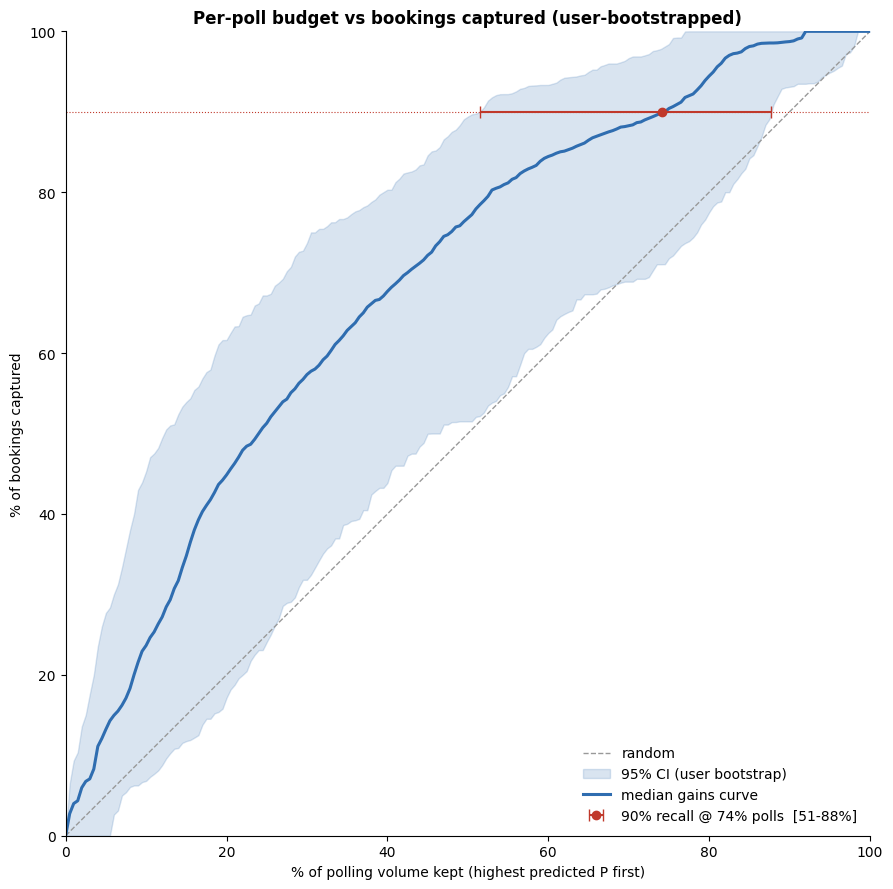

90% of bookings for 74% of polls (95% CI 51-88%)


In [ ]:
import matplotlib.pyplot as plt

# if your calibrated OOF preds are an array: df_train = df_train.assign(p_oof_cal=p_oof_cal)
df_test = df_test.assign(p_oof_cal=p_final_cal)
res = gains_bootstrap(df_test, pred_col="p_oof_cal")
g, lo, med, hi = res["grid"]*100, res["lo"]*100, res["med"]*100, res["hi"]*100
b_lo, b_med, b_hi = res["budget_ci"]*100

fig, ax = plt.subplots(figsize=(9, 9))
ax.plot([0,100],[0,100], "--", color="0.6", lw=1, label="random")
ax.fill_between(g, lo, hi, color="#2f6db0", alpha=0.18, label="95% CI (user bootstrap)")
ax.plot(g, med, color="#2f6db0", lw=2.2, label="median gains curve")
ax.errorbar(b_med, 90, xerr=[[b_med-b_lo],[b_hi-b_med]], fmt="o", color="#c0392b",
            capsize=4, zorder=6,
            label=f"90% recall @ {b_med:.0f}% polls  [{b_lo:.0f}-{b_hi:.0f}%]")
ax.axhline(90, color="#c0392b", ls=":", lw=0.8)
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect("equal")
ax.set_xlabel("% of polling volume kept (highest predicted P first)")
ax.set_ylabel("% of bookings captured")
ax.set_title("Per-poll budget vs bookings captured (user-bootstrapped)", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

print(f"90% of bookings for {res['budget']*100:.0f}% of polls "
      f"(95% CI {b_lo:.0f}-{b_hi:.0f}%)")